In [1]:
!unzip -q -o ./data/sirius-cv-contest.zip -d ./data/

In [2]:
import pandas as pd
import numpy as np

import os

from sklearn.model_selection import train_test_split

import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader, Subset

from icecream import ic
from tqdm.cli import tqdm
from tqdm import trange


In [3]:
class MyDataset(Dataset):
    def __init__(self, path, transform=None, is_test=False):
        super().__init__()

        self.path = path
        self.transform = transform
        self.is_test = is_test
        self.imgs = []

        files: list[str] = [i for i in os.walk(path)][0][2]
        for file in files:
            img_path = os.path.join(self.path, file)
            l_ind = file.find('label')
            
            label = 0
            if not is_test:
                label = file[l_ind + 5:-4]
            
            self.imgs.append((img_path, label))
    
    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, index):
        img_path = self.imgs[index][0]
        label = self.imgs[index][1]

        img = Image.open(img_path).convert("L")

        if self.transform:
            img = self.transform(img)
        
        return (img, label)

            


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.255))
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.255))
])


In [5]:
all_dataset = MyDataset("./data/train_top10", train_transforms)
test_dataset = MyDataset("./data/test_filtered", test_transforms, is_test=True)

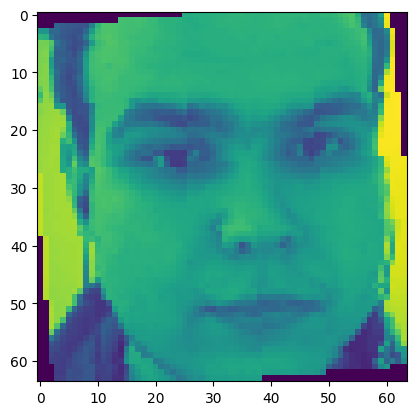

In [6]:
img_idx = np.random.randint(0, len(all_dataset))
img = all_dataset[img_idx][0].numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)

In [7]:
labels = [all_dataset[i][1] for i in range(len(all_dataset))]
train_idx, val_idx = train_test_split(range(len(all_dataset)), test_size=0.25, stratify=labels)
len(train_idx), len(val_idx)

(395, 132)

In [8]:
train_dataset = torch.ut
test_dataset = MyDataset("./data/test_filtered", test_transforms, is_test=True)

AttributeError: module 'torch' has no attribute 'ut'

In [ ]:
len(set(labels))

10

In [ ]:
def train_loop(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, optimizer: torch.optim.AdamW, criterion = nn.CrossEntropyLoss(), model_name = "best_model.pth", n_epoches=100):
    device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []
    best_metric = -np.inf

    for epoch in trange(n_epoches):
        model.train()
        cur_train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            
            optimizer.zero_grad()
            loss = criterion(pred, y_batch)
            loss.backwards()
            optimizer.step()

            cur_train_loss += loss.item()
        train_losses.append(cur_train_loss / len(train_loader))

        model.eval()
        cur_val_loss = 0
        true_pred = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)

                loss = criterion(pred, y_batch)

                cur_val_loss += loss.item()
                
                pred = pred.detach().cpu().numpy()
                y_batch = y_batch.detach().cpu().numpy()
                true_pred += sum(pred == y_batch)
        val_losses.append(cur_val_loss / len(val_loader))
        cur_val_metric = true_pred / len(val_loader.dataset)

        if cur_val_metric > best_metric:
            print("!!! New best Model !!!")
            torch.save(model.state_dict(), f"./models/{model_name}")
            best_metric = cur_val_metric
        
        val_metrics.append(cur_val_metric)

        print(f"{epoch}/{n_epoches}, {cur_val_metric}")

        if epoch % 10 == 0 or epoch == n_epoches - 1:
            if epoch == 0:
                continue
            
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label='Train')
            axs[0].plot(val_losses, label='Val')
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("val acc")
            axs[1].plot(val_metrics)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()


In [ ]:
train_loader = DataLoader(Subset(all_dataset, train_idx), batch_size=128, shuffle=True, num_workers=8, persistent_workers=True)
val_loader = DataLoader(Subset(all_dataset, val_idx), batch_size=128, shuffle=False, num_workers=8, persistent_workers=True)

NameError: name 'all_dataset' is not defined

In [ ]:
model = torchvision.models.resnet18()
model.fc = nn.Linear(512, 10)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_loop(model, )